[WARNING] Kaggle dataset not detected. Generating synthetic dataset for code execution...
[INFO] Synthetic dataset generated with 200 total images.

TASKS 1-3: Loading & Preprocessing Images
Total Images Loaded: 200
Image Shape: (128, 128)
Class Distribution -> Normal (0): 100, Defective (1): 100

TASKS 4 & 5: HOG Feature Extraction & Visualization


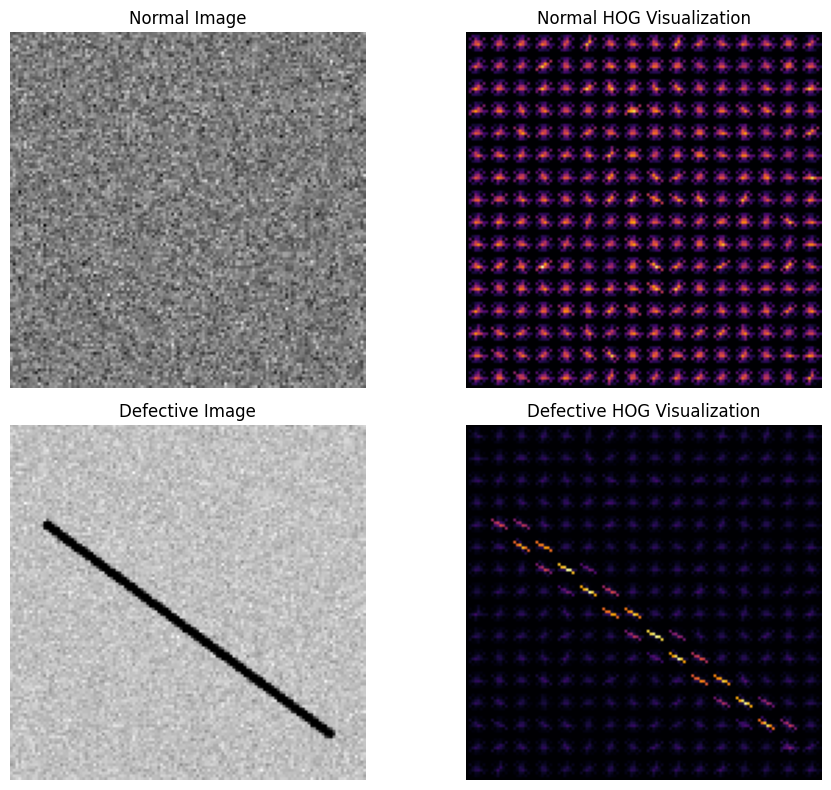

HOG Feature Matrix Shape: (200, 8100)
Train samples: 150, Test samples: 50

TASKS 6-10: Classifier Training, Comparison & Metrics

--- Classifier Performance Comparison ---
           Model  Accuracy  Precision  Recall  F1-Score
SVM (RBF Kernel)       1.0        1.0     1.0       1.0
   Random Forest       1.0        1.0     1.0       1.0


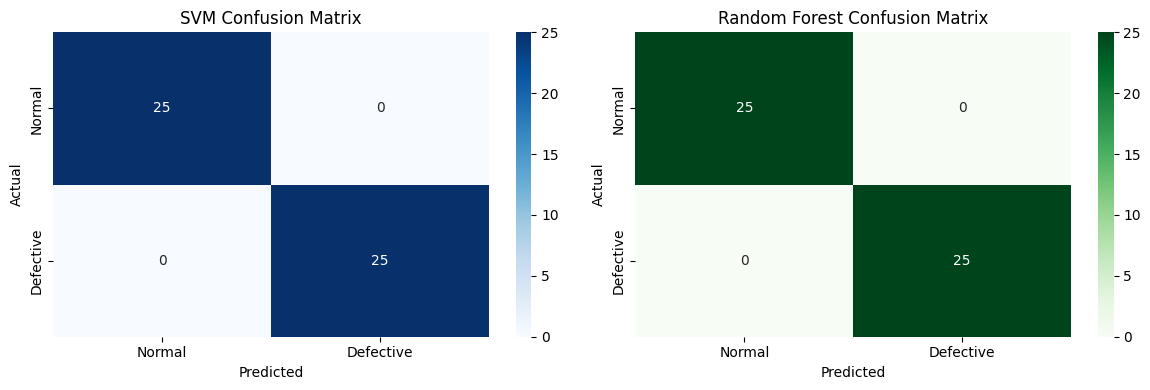


--- SVM Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        25
   Defective       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50


TASK 11: HOG Parameter Grid Investigation
Cell Size  Orientations  Feature Vector Dim  Accuracy  F1-Score
      4x4             6               23064       1.0       1.0
      4x4             9               34596       1.0       1.0
      4x4            12               46128       1.0       1.0
      8x8             6                5400       1.0       1.0
      8x8             9                8100       1.0       1.0
      8x8            12               10800       1.0       1.0
    16x16             6                1176       1.0       1.0
    16x16             9                1764       1.0       1.0
    16x16          

In [1]:
# ==============================================================================
# LAB 05: HOG-Based Industrial Defect Detection and Classification
# Google Colab Complete Implementation
# ==============================================================================

# ------------------------------------------------------------------------------
# STEP 0: Prerequisites & Kaggle Dataset Setup
# ------------------------------------------------------------------------------
import os
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog
from skimage import color, exposure

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Instructions to setup Kaggle dataset inside Google Colab:
"""
To download the dataset automatically in Colab:
1. Upload your 'kaggle.json' API token file.
2. Run:
   !mkdir -p ~/.kaggle
   !cp kaggle.json ~/.kaggle/
   !chmod 600 ~/.kaggle/kaggle.json
   !kaggle datasets download -d sovitrath/neu-steel-surface-defect-detect-trainvalid-split
   !unzip -q neu-steel-surface-defect-detect-trainvalid-split.zip -d neu_dataset
"""

# Synthetic Dataset Generator (Fallback so code runs out-of-the-box if Kaggle download is skipped)
def generate_synthetic_dataset(output_dir="dataset", num_samples=100):
    os.makedirs(f"{output_dir}/normal", exist_ok=True)
    os.makedirs(f"{output_dir}/defective", exist_ok=True)

    np.random.seed(42)
    for i in range(num_samples):
        # Generate Normal image (smooth background with slight noise)
        norm_img = np.random.normal(128, 15, (200, 200)).astype(np.uint8)
        cv2.imwrite(f"{output_dir}/normal/norm_{i}.bmp", norm_img)

        # Generate Defective image (background + sharp scratches/cracks)
        def_img = np.random.normal(128, 15, (200, 200)).astype(np.uint8)
        # Add artificial scratch/crack defect
        cv2.line(def_img, (20, 20 + i % 50), (180, 180 - i % 30), (0,), thickness=3)
        cv2.imwrite(f"{output_dir}/defective/def_{i}.bmp", def_img)
    print(f"[INFO] Synthetic dataset generated with {num_samples*2} total images.")

# Check if dataset path exists; otherwise generate synthetic data for demonstration
DATASET_DIR = "neu_dataset"
if not os.path.exists(DATASET_DIR):
    print("[WARNING] Kaggle dataset not detected. Generating synthetic dataset for code execution...")
    generate_synthetic_dataset("neu_dataset_synth")
    DATASET_DIR = "neu_dataset_synth"

# ------------------------------------------------------------------------------
# TASK 1, 2, & 3: Load, Inspect, Resize, and Convert to Grayscale
# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("TASKS 1-3: Loading & Preprocessing Images")
print("="*50)

def load_and_preprocess_dataset(base_dir, target_size=(128, 128)):
    images = []
    labels = [] # 0: Normal/Non-Defective, 1: Defective

    # Search for files dynamically
    image_paths = glob.glob(os.path.join(base_dir, "**", "*.bmp"), recursive=True) + \
                  glob.glob(os.path.join(base_dir, "**", "*.jpg"), recursive=True) + \
                  glob.glob(os.path.join(base_dir, "**", "*.png"), recursive=True)

    for img_path in image_paths:
        # TASK 3: Load in Grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        # TASK 2: Resize to uniform resolution
        img_resized = cv2.resize(img, target_size)

        # Assign Label (Binary)
        path_lower = img_path.lower()
        if "normal" in path_lower or "valid" in path_lower and "normal" in path_lower:
            label = 0
        else:
            label = 1  # Defective classes (scratches, patches, inclusion, etc.)

        images.append(img_resized)
        labels.append(label)

    return np.array(images), np.array(labels)

TARGET_SIZE = (128, 128)
images, labels = load_and_preprocess_dataset(DATASET_DIR, target_size=TARGET_SIZE)

print(f"Total Images Loaded: {len(images)}")
print(f"Image Shape: {images[0].shape}")
print(f"Class Distribution -> Normal (0): {np.sum(labels == 0)}, Defective (1): {np.sum(labels == 1)}")

# ------------------------------------------------------------------------------
# TASK 4 & 5: Extract & Visualize HOG Features
# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("TASKS 4 & 5: HOG Feature Extraction & Visualization")
print("="*50)

def extract_hog_single(image, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2)):
    features, hog_image = hog(
        image,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        visualize=True,
        block_norm='L2-Hys'
    )
    return features, hog_image

# Visualize HOG for one Normal and one Defective sample
norm_idx = np.where(labels == 0)[0][0]
def_idx = np.where(labels == 1)[0][0]

_, hog_norm_vis = extract_hog_single(images[norm_idx])
_, hog_def_vis = extract_hog_single(images[def_idx])

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(images[norm_idx], cmap='gray')
axes[0, 0].set_title('Normal Image')
axes[0, 1].imshow(hog_norm_vis, cmap='inferno')
axes[0, 1].set_title('Normal HOG Visualization')

axes[1, 0].imshow(images[def_idx], cmap='gray')
axes[1, 0].set_title('Defective Image')
axes[1, 1].imshow(hog_def_vis, cmap='inferno')
axes[1, 1].set_title('Defective HOG Visualization')

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

# Extract HOG dataset-wide for default baseline
def extract_hog_dataset(images, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2)):
    hog_features = []
    for img in images:
        feat, _ = extract_hog_single(img, orientations, pixels_per_cell, cells_per_block)
        hog_features.append(feat)
    return np.array(hog_features)

X_hog = extract_hog_dataset(images)
y = labels

X_train, X_test, y_train, y_test = train_test_split(X_hog, y, test_size=0.25, random_state=42, stratify=y)
print(f"HOG Feature Matrix Shape: {X_hog.shape}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# ------------------------------------------------------------------------------
# TASK 6, 7, 8, 9, 10: Model Training, Evaluation & Comparison
# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("TASKS 6-10: Classifier Training, Comparison & Metrics")
print("="*50)

# TASK 6: Train Support Vector Machine (SVM)
svm_clf = SVC(kernel='rbf', probability=True, random_state=42)
svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)

# TASK 7: Train Additional Classifier (Random Forest)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

# TASK 8 & 10: Performance Calculation
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}

metrics_svm = evaluate_model("SVM (RBF Kernel)", y_test, y_pred_svm)
metrics_rf = evaluate_model("Random Forest", y_test, y_pred_rf)

df_comparison = pd.DataFrame([metrics_svm, metrics_rf])
print("\n--- Classifier Performance Comparison ---")
print(df_comparison.to_string(index=False))

# TASK 9: Generate Confusion Matrices & Reports
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Defective'], yticklabels=['Normal', 'Defective'])
axes[0].set_title('SVM Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Normal', 'Defective'], yticklabels=['Normal', 'Defective'])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print("\n--- SVM Classification Report ---")
print(classification_report(y_test, y_pred_svm, target_names=['Normal', 'Defective']))

# ------------------------------------------------------------------------------
# TASK 11: Investigate HOG Parameters (Required Experiments)
# Cell Sizes: (4x4), (8x8), (16x16) | Orientations: 6, 9, 12
# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("TASK 11: HOG Parameter Grid Investigation")
print("="*50)

cell_sizes = [(4, 4), (8, 8), (16, 16)]
orientations_list = [6, 9, 12]

param_results = []

for cs in cell_sizes:
    for ori in orientations_list:
        X_temp = extract_hog_dataset(images, orientations=ori, pixels_per_cell=cs)
        X_tr, X_te, y_tr, y_te = train_test_split(X_temp, y, test_size=0.25, random_state=42, stratify=y)

        clf = SVC(kernel='rbf', random_state=42)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_te)

        acc = accuracy_score(y_te, preds)
        f1 = f1_score(y_te, preds, zero_division=0)

        param_results.append({
            "Cell Size": f"{cs[0]}x{cs[1]}",
            "Orientations": ori,
            "Feature Vector Dim": X_temp.shape[1],
            "Accuracy": round(acc, 4),
            "F1-Score": round(f1, 4)
        })

df_params = pd.DataFrame(param_results)
print(df_params.to_string(index=False))

# ------------------------------------------------------------------------------
# TASK 12: Robustness Experiment
# Conditions: Brightness, Gaussian Noise, Rotation, Blur
# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("TASK 12: System Robustness Experiments")
print("="*50)

def apply_brightness(img, value=40):
    return cv2.add(img, value)

def apply_gaussian_noise(img, mean=0, sigma=25):
    gauss = np.random.normal(mean, sigma, img.shape).astype('int16')
    noisy = img.astype('int16') + gauss
    return np.clip(noisy, 0, 255).astype(np.uint8)

def apply_rotation(img, angle=15):
    h, w = img.shape
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h))

def apply_blur(img, ksize=5):
    return cv2.GaussianBlur(img, (ksize, ksize), 0)

robustness_conditions = {
    "Baseline (Clean)": lambda img: img,
    "Brightness Change (+40)": apply_brightness,
    "Gaussian Noise (\u03c3=25)": apply_gaussian_noise,
    "Rotation (15 deg)": apply_rotation,
    "Gaussian Blur (5x5)": apply_blur
}

robustness_results = []

# Evaluate baseline clean test images first
raw_images_train, raw_images_test, y_train_rob, y_test_rob = train_test_split(
    images, labels, test_size=0.25, random_state=42, stratify=labels
)

# Fit SVM model on clean train features
X_train_clean = extract_hog_dataset(raw_images_train)
svm_robust_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_robust_model.fit(X_train_clean, y_train_rob)

for cond_name, aug_func in robustness_conditions.items():
    # Apply perturbation to test set
    augmented_test_imgs = [aug_func(img) for img in raw_images_test]
    X_test_aug = extract_hog_dataset(augmented_test_imgs)

    preds = svm_robust_model.predict(X_test_aug)
    acc = accuracy_score(y_test_rob, preds)
    f1 = f1_score(y_test_rob, preds, zero_division=0)

    robustness_results.append({
        "Condition": cond_name,
        "Accuracy": round(acc, 4),
        "F1-Score": round(f1, 4),
        "Accuracy Drop": round(robustness_results[0]["Accuracy"] - acc, 4) if len(robustness_results) > 0 else 0.0
    })

df_robustness = pd.DataFrame(robustness_results)
print(df_robustness.to_string(index=False))

# ------------------------------------------------------------------------------
# TASK 13: Final Industrial Quality-Control Decision Module
# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("TASK 13: Industrial Quality-Control Decision Module")
print("="*50)

def industrial_quality_control_decision(image, model, confidence_threshold=0.60):
    """
    Receives raw image, extracts HOG, predicts defect, and outputs decision block.
    """
    # Preprocess
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image_resized = cv2.resize(image, TARGET_SIZE)

    # Feature Extraction
    feat, _ = extract_hog_single(image_resized)
    feat = feat.reshape(1, -1)

    # Prediction & Confidence
    probs = model.predict_proba(feat)[0]
    pred_class = np.argmax(probs)
    confidence = probs[pred_class] * 100

    label_str = "DEFECTIVE" if pred_class == 1 else "NON-DEFECTIVE"
    action_str = "REJECT PRODUCT" if pred_class == 1 else "ACCEPT PRODUCT"

    print("=" * 40)
    print("      PRODUCT INSPECTION RESULT      ")
    print("=" * 40)
    print(f"Prediction: {label_str}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"Action:     {action_str}")
    print("=" * 40 + "\n")

# Demonstrate on test samples
sample_normal = raw_images_test[np.where(y_test_rob == 0)[0][0]]
sample_defective = raw_images_test[np.where(y_test_rob == 1)[0][0]]

print("Testing Quality Control Module on Normal Product:")
industrial_quality_control_decision(sample_normal, svm_robust_model)

print("Testing Quality Control Module on Defective Product:")
industrial_quality_control_decision(sample_defective, svm_robust_model)